This notebook trains a model using presaved spectrogram images from the Muse2 dataset. For now there is only the TP9 channel.

In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Mon Jul 29 07:33:50 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   41C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
try:
    DataSequence = get_keras_submodule('utils').Sequence
except:
    try:
        # Work-around for TF-2.9
        from keras.utils.data_utils import Sequence
        DataSequence = Sequence
    except:
        DataSequence = object

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

folder_path = '/content/drive/My Drive/ML project'

# Check if the path exists
if os.path.exists(folder_path):
    print("Folder found.")
else:
    print("Folder not found.")

Folder found.


In [7]:
#import optuna
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import json
from sklearn.preprocessing import MinMaxScaler
import random
from scipy.signal import sosfiltfilt, butter, filtfilt, iirnotch


import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

#from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hann


In [8]:
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.15.0
Num GPUs Available:  1


In [9]:
# Declare image constats
image_height = 6400
image_width = 200
BATCH_SIZE = 32
N_COLOR_CHANNELS = 3
N_CLASSES = 10
file_load_path = '/content/drive/My Drive/ML project/MindBigData64_Mnist2022-Morlet_v0.016_divided11'

# Load the images into a dataset using keras
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(batch_size=BATCH_SIZE, validation_split=0.2, directory=file_load_path, shuffle=True, color_mode='rgb', image_size=(image_height, image_width), subset='training', seed=0)
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(batch_size=BATCH_SIZE, validation_split=0.2, directory=file_load_path, shuffle=True, color_mode='rgb', image_size=(image_height, image_width), subset='validation', seed=0)


Found 1161 files belonging to 10 classes.
Using 929 files for training.
Found 1161 files belonging to 10 classes.
Using 232 files for validation.


In [10]:
train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [11]:
val_dataset = val_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [12]:

for images, labels in train_dataset.take(1):
    print(images.shape)  # (32, 256, 256, 3)
    print(labels.shape)  # (32,)
    #print(type(images))  # <class 'tensorflow.python.framework.ops.EagerTensor'>
    #print(type(labels))

(32, 6400, 200, 3)
(32,)


In [13]:
# Visualize a few of the images and labels
plt.figure(figsize=(12, 12))
for images, labels in train_dataset.take(1):
    for i in range(1):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
plt.show()

In [14]:
def slice_horizontal_channels(image, label, brain_channels):
    # Slice the image horizontally from start_col to end_col
    step=image_height//brain_channels
    size_channel=image_height//64
    slice_ranges = []
    for i in range(0, image_height, step):
        slice_ranges.append((i, i+size_channel))
    slices = []
    for start_col, end_col in slice_ranges:
        slices.append(image[:, start_col:end_col, :, :])
    # Concatenate the slices along the column dimension
    #print(slices)
    image = tf.concat(slices, axis=1)
    #print(image.shape)
    return image, label

In [15]:
brain_channels=16
new_image_height=(image_height//64)*brain_channels
train_dataset = train_dataset.map(lambda image, label: slice_horizontal_channels(image, label, brain_channels))
val_dataset = val_dataset.map(lambda image, label: slice_horizontal_channels(image, label, brain_channels))

In [16]:
for images, labels in train_dataset.take(1):
    print(images.shape)  # (32, 256, 256, 3)
    print(labels.shape)  # (32,)
    #print(type(images))  # <class 'tensorflow.python.framework.ops.EagerTensor'>
    #print(type(labels))

(32, 1600, 200, 3)
(32,)


In [17]:
# Rescale the datasets
rescale = tf.keras.Sequential([tf.keras.layers.experimental.preprocessing.Rescaling(1./255)])
train_dataset = train_dataset.map(lambda x, y: (rescale(x, training=True), y))
val_dataset = val_dataset.map(lambda x, y: (rescale(x, training=True), y))

# One hot encode the labels
train_dataset = train_dataset.map(lambda x, y: (x, tf.one_hot(y, depth=N_CLASSES)))
val_dataset = val_dataset.map(lambda x, y: (x, tf.one_hot(y, depth=N_CLASSES)))


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:

#train_dataset = train_dataset.repeat()
#val_dataset = val_dataset.repeat()

# TRAINING

In [20]:
# Import the necessary network layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, MaxPooling2D, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [21]:
 policy = tf.keras.mixed_precision.Policy('mixed_float16')
 tf.keras.mixed_precision.set_global_policy(policy)

In [22]:

# Try building a much simpler model
model = Sequential()
model.add(Input(shape=(new_image_height, image_width, N_COLOR_CHANNELS)))
model.add(Conv2D(filters=16, kernel_size=(9, 6), activation=tf.keras.layers.LeakyReLU(alpha=0.01), strides=(4, 4)))
BatchNormalization()
model.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation=tf.keras.layers.LeakyReLU(alpha=0.01)))
BatchNormalization()
#model.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))
model.add(Conv2D(filters=64, kernel_size=(6, 3), activation=tf.keras.layers.LeakyReLU(alpha=0.01), strides=(2, 2)))
BatchNormalization()
#model.add(MaxPooling2D(pool_size=(2, 2), strides=(1, 1)))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation=tf.keras.layers.LeakyReLU(alpha=0.01)))
BatchNormalization()
model.add(MaxPooling2D(pool_size=(8, 2), strides=(1, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(rate=0.5))
model.add(Dense(N_CLASSES, activation='softmax'))

learning_rate = 0.0001  # Set your desired learning rate here
optimizer = Adam(learning_rate=learning_rate)

model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 398, 49, 16)       2608      
                                                                 
 max_pooling2d (MaxPooling2  (None, 397, 48, 16)       0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 395, 46, 32)       4640      
                                                                 
 conv2d_2 (Conv2D)           (None, 195, 22, 64)       36928     
                                                                 
 conv2d_3 (Conv2D)           (None, 193, 20, 128)      73856     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 186, 19, 128)      0         
 g2D)                                                 

In [23]:
hist = model.fit(train_dataset, epochs=60, validation_data=val_dataset, batch_size=32)

Epoch 1/60
30/30 [==============================] - 96s 3s/step - loss: 2.5749 - accuracy: 0.1098 - val_loss: 2.3035 - val_accuracy: 0.0819
Epoch 2/60
30/30 [==============================] - 4s 112ms/step - loss: 2.3091 - accuracy: 0.1163 - val_loss: 2.3027 - val_accuracy: 0.1207
Epoch 3/60
30/30 [==============================] - 4s 110ms/step - loss: 2.3027 - accuracy: 0.1195 - val_loss: 2.3027 - val_accuracy: 0.1207
Epoch 4/60
30/30 [==============================] - 4s 115ms/step - loss: 2.3022 - accuracy: 0.1195 - val_loss: 2.3021 - val_accuracy: 0.1207
Epoch 5/60
30/30 [==============================] - 4s 114ms/step - loss: 2.3029 - accuracy: 0.1184 - val_loss: 2.3032 - val_accuracy: 0.1207
Epoch 6/60
30/30 [==============================] - 4s 109ms/step - loss: 2.3022 - accuracy: 0.1195 - val_loss: 2.3032 - val_accuracy: 0.1207
Epoch 7/60
30/30 [==============================] - 4s 111ms/step - loss: 2.3023 - accuracy: 0.1195 - val_loss: 2.3021 - val_accuracy: 0.1207
Epoch 8/

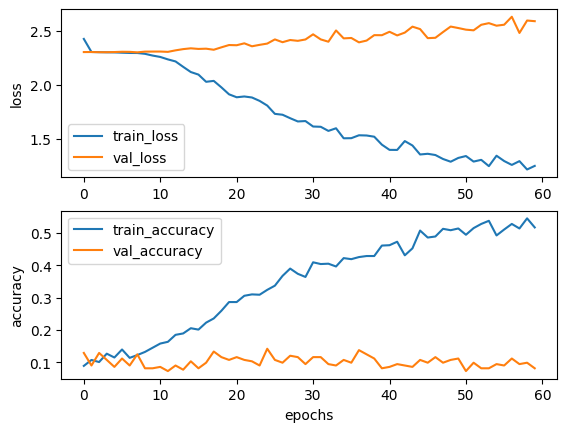

In [36]:
# Plot the training history
fig, ax = plt.subplots(2)
# fig.suptitle(model_name)
ax[0].set(ylabel='loss')
ax[1].set(xlabel='epochs', ylabel='accuracy')

ax[0].plot(hist.history['loss'], label='train_loss')
ax[0].plot(hist.history['val_loss'], label='val_loss')
ax[0].legend()

ax[1].plot(hist.history['accuracy'], label='train_accuracy')
ax[1].plot(hist.history['val_accuracy'], label='val_accuracy')
ax[1].legend()

plt.show()


In [ ]:
# Try building the model from the paper
dropout2=0.2

model = Sequential()
model.add(Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, N_COLOR_CHANNELS)))
model.add(Conv2D(filters=32, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(8, 8), strides=2))
model.add(Conv2D(64, kernel_size=(5, 5), activation='relu'))
#model.add(MaxPooling2D(pool_size=(4, 4), strides=2))
model.add(Conv2D(16, kernel_size=(5, 5), activation='relu'))
model.add(MaxPooling2D(pool_size=(4, 4), strides=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(dropout2))
model.add(Dense(16, activation='relu'))
model.add(Dense(N_CLASSES, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_34 (Conv2D)          (None, 636, 36, 32)       2432      
                                                                 
 max_pooling2d_22 (MaxPooli  (None, 315, 15, 32)       0         
 ng2D)                                                           
                                                                 
 conv2d_35 (Conv2D)          (None, 311, 11, 64)       51264     
                                                                 
 conv2d_36 (Conv2D)          (None, 307, 7, 16)        25616     
                                                                 
 max_pooling2d_23 (MaxPooli  (None, 152, 2, 16)        0         
 ng2D)                                                           
                                                                 
 flatten_6 (Flatten)         (None, 4864)            

In [ ]:
hist = model.fit(train_dataset, epochs=5, validation_data=val_dataset)

Epoch 1/5
 8/59 [===>..........................] - ETA: 1:30 - loss: 0.6923 - accuracy: 0.5508

KeyboardInterrupt: 

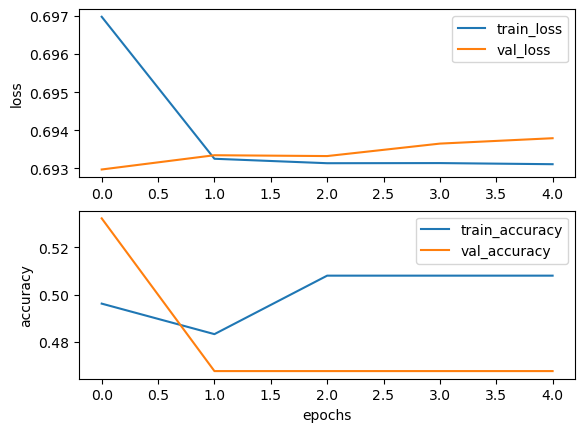

In [ ]:

# Plot the training history
fig, ax = plt.subplots(2)
# fig.suptitle(model_name)
ax[0].set(ylabel='loss')
ax[1].set(xlabel='epochs', ylabel='accuracy')

ax[0].plot(hist.history['loss'], label='train_loss')
ax[0].plot(hist.history['val_loss'], label='val_loss')
ax[0].legend()

ax[1].plot(hist.history['accuracy'], label='train_accuracy')
ax[1].plot(hist.history['val_accuracy'], label='val_accuracy')
ax[1].legend()

plt.show()
